In [3]:
# @title 물성라이브러리 설치 code
!pip install cantera
!pip install CoolProp
import cantera as ct
print(ct.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 97.9 MB/s eta 0:00:00
3.2.0


In [5]:
# @title 조건 입력 code

# NOTE: C_to_K, K_to_C, bar_to_Pa, Pa_to_bar 함수는 이제 3bf51bf5 셀에 정의됩니다.

params = {

    "v_lng_tank_m3_per_hr": 550.0, # LNG 체적 유량 (m3/h) - 입력
    "v_bog_tank_m3_per_hr": 18100.0, # BOG 체적 유량 (m3/h) - 입력

    # LNG 저장 탱크 및 실제 펌프 입구 조건
    "T_lng_tank": C_to_K(-162.0),
    "P_lng_tank": bar_to_Pa(5.0),

    # LNG 2차 펌프 출구는 펌핑 후 가열된다고 가정합니다.
    # 이것은 LNG 스트림의 디슈퍼히터 이전의 목표 온도입니다.
    "T_lng_pump_out_heated": C_to_K(-130.0),

    # LNG 2차 펌프 출구 압력
    "P_lng_high": bar_to_Pa(80.0),

    "T_bog_tank": C_to_K(-100.0),
    "P_bog_tank": bar_to_Pa(1.157),
    "P_bog_comp_out": bar_to_Pa(9.91), # 단일 BOG 압축기의 목표 출구 압력

    "pump_eta": 0.75,
    "comp_eta": 0.665,
    "m_desuperheater_spray_kg_per_hr": 9000.0 # 디슈퍼히터 LNG 스프레이 유량 (kg/h) - 입력
}



In [9]:
# @title
import os
import pandas as pd
from CoolProp.CoolProp import PropsSI

methane_mass_fraction = 0.95 # BOG용: 메탄 95%
nitrogen_mass_fraction = 0.05 # BOG용: 질소 5%

#methane_mass_fraction = 0.79 # BOG용: 메탄 79%
#nitrogen_mass_fraction = 0.21 # BOG용: 질소 21%
FLUID = f"Methane[{methane_mass_fraction}]&Nitrogen[{nitrogen_mass_fraction}]" # BOG용 유체

# LNG는 이제 순수 메탄으로 직접 정의됩니다.
methane_mass_fraction_lng = 1.0 # LNG용: 메탄 100%
nitrogen_mass_fraction_lng = 0.0 # LNG용: 질소 0%
FLUID_LNG = 'Methane' # LNG용 유체 (순수 메탄)

# 조성 문자열 동적 생성
composition_str_bog = f"Methane {int(methane_mass_fraction*100)}%, Nitrogen {int(nitrogen_mass_fraction*100)}%"
composition_str_lng = f"Methane {int(methane_mass_fraction_lng*100)}%, Nitrogen {int(nitrogen_mass_fraction_lng*100)}%"

def C_to_K(T_C):
    # 섭씨 온도를 켈빈 온도로 변환
    return T_C + 273.15

def K_to_C(T_K):
    # 켈빈 온도를 섭씨 온도로 변환
    return T_K - 273.15

def bar_to_Pa(P_bar):
    # bar 단위를 파스칼(Pa)로 변환
    return P_bar * 1e5

def Pa_to_bar(P_Pa):
    # 파스칼(Pa) 단위를 bar로 변환
    return P_Pa / 1e5

# =====================================================
# 1. CoolProp 속성 도우미 함수들
# =====================================================

def h_TP(T, P, fluid):
    # 온도(T)와 압력(P)으로 질량 엔탈피(Hmass) 계산
    try:
        return PropsSI("Hmass", "T", T, "P", P, fluid)
    except ValueError:
        # 오류 발생 시 약간의 온도 보정
        return PropsSI("Hmass", "T", T + 0.1, "P", P, fluid)

def s_TP(T, P, fluid):
    # 온도(T)와 압력(P)으로 질량 엔트로피(Smass) 계산
    try:
        return PropsSI("Smass", "T", T, "P", P, fluid)
    except ValueError:
        # 오류 발생 시 약간의 온도 보정
        return PropsSI("Smass", "T", T + 0.1, "P", P, fluid)

def T_Ph(P, h, fluid):
    # 압력(P)과 질량 엔탈피(h)로 온도(T) 계산
    return PropsSI("T", "P", P, "Hmass", h, fluid)

def h_PS(P, s, fluid):
    # 압력(P)과 질량 엔트로피(s)로 질량 엔탈피(Hmass) 계산 (등엔트로피 과정)
    return PropsSI("Hmass", "P", P, "Smass", s, fluid)

def rho_TP(T, P, fluid):
    # 온도(T)와 압력(P)으로 질량 밀도(Dmass) 계산
    try:
        return PropsSI("Dmass", "T", T, "P", P, fluid)
    except ValueError:
        # 오류 발생 시 약간의 온도 보정
        return PropsSI("Dmass", "T", T + 0.1, "P", P, fluid)

# =====================================================
# 2. 컴포넌트 모델
# =====================================================

def liquid_pump(m_dot, T_in, P_in, P_out, eta=0.75, fluid=FLUID_LNG):
    # 액체 펌프 모델
    h_in = h_TP(T_in, P_in, fluid)
    rho = rho_TP(T_in, P_in, fluid)

    if rho < 100.0:
        # 펌프 입구 밀도가 너무 낮으면 오류 발생 (액체가 아닌 증기/이상 상태일 가능성)
        raise ValueError(
            f"액체 펌프 입구 밀도가 너무 낮습니다 ({rho:.3f} kg/m3). "
            "입구는 증기/이상 상태일 가능성이 높습니다. "
            "펌프 입구 압력을 높이거나 펌프 입구 온도를 낮추십시오."
        )

    # 펌프 일 (엔탈피 변화)
    dh = (P_out - P_in) / rho / eta
    h_out = h_in + dh
    T_out = T_Ph(P_out, h_out, fluid)
    W = m_dot * dh

    return {
        "T_out": T_out, # 출구 온도
        "P_out": P_out, # 출구 압력
        "h_out": h_out, # 출구 엔탈피
        "W": W,         # 펌프 동력
        "rho_in": rho,  # 입구 밀도
    }

def compressor(m_dot, T_in, P_in, P_out, eta=0.75, fluid=FLUID):
    # 압축기 모델
    if m_dot <= 0:
        # 질량 유량이 없으면 압축기 동력은 0
        return {
            "T_out": T_in,
            "P_out": P_out,
            "h_out": h_TP(T_in, P_out, fluid),
            "W": 0.0,
        }

    h_in = h_TP(T_in, P_in, fluid)
    s_in = s_TP(T_in, P_in, fluid)
    # 등엔트로피 출구 엔탈피
    h_out_s = h_PS(P_out, s_in, fluid)
    # 실제 출구 엔탈피 (효율 반영)
    h_out = h_in + (h_out_s - h_in) / eta
    T_out = T_Ph(P_out, h_out, fluid)
    # 압축기 동력
    W = m_dot * (h_out - h_in)

    return {
        "T_out": T_out,
        "P_out": P_out,
        "h_out": h_out,
        "W": W,
    }

def heat_exchanger_effectiveness(
    m_cold,
    T_cold_in,
    P_cold,
    fluid_cold,
    m_hot,
    T_hot_in,
    P_hot,
    fluid_hot,
    effectiveness=0.60,
    min_delta_T=3.0,
):
    """
    일반적인 열교환기 유용도(effectiveness) 모델.
    뜨거운 스트림이 차가운 스트림에 열을 전달합니다.
    """
    if m_hot <= 0 or effectiveness <= 0:
        # 뜨거운 유량 또는 유용도가 0 이하면 열 전달 없음
        return {
            "Q": 0.0,
            "T_cold_out": T_cold_in,
            "h_cold_out": h_TP(T_cold_in, P_cold, fluid_cold),
            "T_hot_out": T_hot_in,
            "h_hot_out": h_TP(T_hot_in, P_hot, fluid_hot),
        }

    h_hot_in = h_TP(T_hot_in, P_hot, fluid_hot)
    h_cold_in = h_TP(T_cold_in, P_cold, fluid_cold)
    # 최소 접근 온도 차이를 고려한 뜨거운 스트림의 최소 온도
    T_hot_min = T_cold_in + min_delta_T
    h_hot_min = h_TP(T_hot_min, P_hot, fluid_hot)

    # 최대 가능한 열량 (뜨거운 스트림 기준)
    Q_max_hot = m_hot * max(h_hot_in - h_hot_min, 0.0)
    # 실제 열 전달량 (유용도 반영)
    Q = effectiveness * Q_max_hot

    # 출구 엔탈피 계산
    h_hot_out = h_hot_in - Q / m_hot
    h_cold_out = h_cold_in + Q / m_cold

    # 출구 온도 계산
    T_hot_out = T_Ph(P_hot, h_hot_out, fluid_hot)
    T_cold_out = T_Ph(P_cold, h_cold_out, fluid_cold)

    return {
        "Q": Q,                             # 열 전달량
        "T_cold_out": T_cold_out,         # 차가운 스트림 출구 온도
        "h_cold_out": h_cold_out,         # 차가운 스트림 출구 엔탈피
        "T_hot_out": T_hot_out,           # 뜨거운 스트림 출구 온도
        "h_hot_out": h_hot_out,           # 뜨거운 스트림 출구 엔탈피
    }

def set_stream_temperature(m_dot, T_in, P, T_target, fluid):
    """
    히터/쿨러를 적용하여 동일 압력에서 스트림 온도를 설정합니다.
    양의 Q는 스트림에 열이 추가됨을 의미합니다.
    """
    h_in = h_TP(T_in, P, fluid)
    h_out = h_TP(T_target, P, fluid)
    # 필요한 열량
    Q = m_dot * (h_out - h_in)

    return {
        "Q": Q,
        "T_out": T_target,
        "P_out": P,
        "h_out": h_out,
    }

# =====================================================
# 3. 다단 HPC 모델 (사용하지 않음)
# =====================================================

def get_hpc_stage_pressures(P_in, P_out, n_stages):
    """
    균등 압력비 단계.
    경계 압력: [P0, P1, ..., Pn]을 반환합니다.
    """
    pr_stage = (P_out / P_in) ** (1.0 / n_stages)
    pressures = [P_in]
    for _ in range(n_stages):
        pressures.append(pressures[-1] * pr_stage)
    pressures[-1] = P_out # 마지막 압력을 P_out으로 강제 설정하여 부동 소수점 오차 방지
    return pressures


def multistage_hpc_no_intercooling(m_dot, T_in, P_in, P_out, eta=0.75, n_stages=3, fluid=FLUID):
    # 중간 냉각 없는 다단 고압 압축기(HPC) 모델
    # 이 함수는 현재 간소화된 모델에서 사용되지 않습니다.
    pressures = get_hpc_stage_pressures(P_in, P_out, n_stages)
    T = T_in
    W_total = 0.0
    stage_results = []

    for i in range(n_stages):
        T_stage_in = T
        comp = compressor(m_dot, T_stage_in, pressures[i], pressures[i + 1], eta, fluid=fluid)
        W_total += comp["W"]
        T = comp["T_out"]

        stage_results.append({
            "stage": i + 1,
            "P_in": pressures[i],
            "P_out": pressures[i + 1],
            "T_in": T_stage_in,
            "T_out": comp["T_out"],
            "W": comp["W"],
        })

    return {
        "T_out": T,
        "P_out": P_out,
        "W": W_total,
        "stages": stage_results,
    }


# =====================================================
# 4. 전체 공정 모델 헬퍼 함수
# =====================================================

def _assemble_simplified_results(
    params,
    m_lng,
    m_bog_total_initial,
    m_desuperheater_spray_kg_per_hr,
    m_bog_after_desuperheater,
    vol_lng_m3_per_hr,
    rho_lng_tank,
    vol_bog_m3_per_hr,
    rho_bog_tank,
    pump_results,
    Q_lng_pump_out_heating,
    T_lng_after_pump_calc,
    P_lng_after_pump,
    T_bog_desuperheater_in,
    T_bog_after_desuperheater,
    comp_bog_results,
    T_bog_comp_out,
    P_bog_comp_out,
    fluid_bog_after_desuperheater, # NEW
    composition_str_bog_after_desuperheater # NEW
):

    # 총 전력 계산
    total_power_mw = (pump_results["W"] + comp_bog_results["W"]) / 1e6
    pump_out_heating_duty_mw = Q_lng_pump_out_heating / 1e6

    return {
        "LNG_TANK_VOL_FLOW_M3_PER_HR": vol_lng_m3_per_hr, # LNG 탱크 체적 유량 (입력)
        "LNG_TANK_RHO_KG_PER_M3": rho_lng_tank, # LNG 탱크 밀도 (계산)
        "LNG_MASS_FLOW_KG_PER_S": m_lng, # LNG 질량 유량 (계산)

        "BOG_TANK_VOL_FLOW_M3_PER_HR": vol_bog_m3_per_hr, # BOG 탱크 체적 유량 (입력)
        "BOG_TANK_RHO_KG_PER_M3": rho_bog_tank, # BOG 탱크 밀도 (계산)
        "BOG_TOTAL_MASS_FLOW_KG_PER_S_INITIAL": m_bog_total_initial, # BOG 질량 유량 (디슈퍼히터 이전) (계산)

        "LNG_TANK_T_C": K_to_C(params["T_lng_tank"]), # LNG 탱크 온도 (섭씨)
        "LNG_TANK_P_BAR": Pa_to_bar(params["P_lng_tank"]), # LNG 탱크 압력 (bar)
        "LNG_PUMP_OUT_CALC_T_C": K_to_C(T_lng_after_pump_calc), # LNG 펌프 출구 계산된 온도 (섭씨)
        "LNG_PUMP_OUT_P_BAR": Pa_to_bar(P_lng_after_pump), # LNG 펌프 출구 압력 (bar)
        "LNG_PUMP_OUT_HEATED_T_C": K_to_C(T_lng_after_pump_calc), # LNG 프리히터 출구 온도 (섭씨) - 디슈퍼히터 이전 가열 목표였으나, 이제는 LNG 스프레이 자체는 계산되지 않고 BOG와 섞임
        "LNG_PUMP_OUT_HEATING_DUTY_MW": pump_out_heating_duty_mw, # LNG 펌프 출구 가열 열량 (MW)

        "BOG_TANK_T_C": K_to_C(params["T_bog_tank"]),     # BOG 탱크 온도 (섭씨)
        "BOG_TANK_P_BAR": Pa_to_bar(params["P_bog_tank"]), # BOG 탱크 압력 (bar)
        "BOG_DESUPERHEATER_IN_T_C": K_to_C(T_bog_desuperheater_in),
        "BOG_DESUPERHEATER_OUT_T_C": K_to_C(T_bog_after_desuperheater), # BOG 디슈퍼히터 출구 온도 (섭씨)
        "BOG_AFTER_DESUPERHEATER_MASS_FLOW_KG_PER_S": m_bog_after_desuperheater, # 디슈퍼히터 후 BOG 질량 유량 (스프레이 LNG 포함) (계산)
        "BOG_COMP_OUT_T_C": K_to_C(T_bog_comp_out),       # BOG 압축기 출구 온도 (섭씨)
        "BOG_COMP_OUT_P_BAR": Pa_to_bar(P_bog_comp_out), # BOG 압축기 출구 압력 (bar)
        "BOG_FINAL_SENDOUT_MASS_FLOW": m_bog_after_desuperheater, # BOG 최종 송출 질량 유량 (압축기 출구) (계산) - 스프레이 LNG 포함
        "DESUPERHEATER_SPRAY_MASS_FLOW_KG_PER_HR": m_desuperheater_spray_kg_per_hr, # 디슈퍼히터 LNG 스프레이 유량 (kg/h)
        "FLUID_BOG_AFTER_DESUPERHEATER": fluid_bog_after_desuperheater, # NEW
        "COMPOSITION_STR_BOG_AFTER_DESUPERHEATER": composition_str_bog_after_desuperheater, # NEW

        "LNG_PUMP_POWER_MW": pump_results["W"] / 1e6,              # LNG 펌프 동력 (MW)
        "BOG_COMP_POWER_MW": comp_bog_results["W"] / 1e6,          # BOG 압축기 동력 (MW)
        "TOTAL_POWER_MW": total_power_mw,                  # 총 동력 (MW)
    }

def simulate_process(params):
    # 주요 매개변수 추출
    v_lng_tank_m3_per_hr = params["v_lng_tank_m3_per_hr"]
    v_bog_tank_m3_per_hr = params["v_bog_tank_m3_per_hr"]
    m_desuperheater_spray_kg_per_hr = params["m_desuperheater_spray_kg_per_hr"]

    # 명확성을 위한 주요 매개변수 추출
    P_lng_tank = params["P_lng_tank"]
    T_lng_tank = params["T_lng_tank"]
    P_lng_high = params["P_lng_high"]

    P_bog_tank = params["P_bog_tank"]
    T_bog_tank = params["T_bog_tank"]
    P_bog_comp_out_target = params["P_bog_comp_out"]

    # LNG 탱크 밀도 계산 및 질량 유량 변환
    rho_lng_tank = rho_TP(T_lng_tank, P_lng_tank, FLUID_LNG)
    m_lng = v_lng_tank_m3_per_hr * rho_lng_tank / 3600.0 # m3/h * kg/m3 / 3600 s/h = kg/s

    # BOG 탱크 밀도 계산 및 질량 유량 변환
    rho_bog_tank = rho_TP(T_bog_tank, P_bog_tank, FLUID)
    m_bog_total_initial = v_bog_tank_m3_per_hr * rho_bog_tank / 3600.0 # m3/h * kg/m3 / 3600 s/h = kg/s


    # 1. LNG 펌프
    pump = liquid_pump(
        m_dot=m_lng,
        T_in=T_lng_tank,
        P_in=P_lng_tank,
        P_out=P_lng_high,
        eta=params["pump_eta"],
        fluid=FLUID_LNG
    )

    T_lng_after_pump_calc = pump["T_out"]
    P_lng_after_pump = pump["P_out"]

    # 펌프 출구 초기 가열 (디슈퍼히터 이전)
    # 이 부분은 이제 디슈퍼히터의 '스프레이' 유량이 되는 LNG 스트림에 대한 목표 온도 설정으로 간주됩니다.
    # 즉, 스프레이될 LNG의 상태를 정의합니다.
    T_lng_pump_out_initial = params["T_lng_pump_out_heated"]

    pump_out_heater = set_stream_temperature(
        m_dot=m_lng,
        T_in=T_lng_after_pump_calc,
        P=P_lng_after_pump,
        T_target=T_lng_pump_out_initial,
        fluid=FLUID_LNG
    )
    Q_lng_pump_out_heating = pump_out_heater["Q"]


    T_lng_spray_in = params["T_lng_pump_out_heated"] # 스프레이되는 LNG의 온도
    P_lng_spray_in = P_lng_after_pump # 스프레이되는 LNG의 압력

    # 2. 디슈퍼히터 (스프레이 혼합 방식)
    # BOG는 탱크에서 바로 디슈퍼히터로 들어갑니다.
    T_bog_desuperheater_in = T_bog_tank # BOG는 탱크에서 직접 들어옴
    P_bog_desuperheater_in = P_bog_tank # BOG는 탱크 압력으로 들어옴

    # 스프레이되는 LNG의 질량 유량 (kg/s)으로 변환
    m_spray_kg_per_s = m_desuperheater_spray_kg_per_hr / 3600.0

    # 에너지 밸런스를 위한 질량 유량 및 엔탈피 계산
    h_bog_in = h_TP(T_bog_desuperheater_in, P_bog_desuperheater_in, FLUID)
    h_spray_in = h_TP(T_lng_spray_in, P_lng_spray_in, FLUID_LNG)

    # 혼합 후 총 질량 유량
    m_bog_after_desuperheater = m_bog_total_initial + m_spray_kg_per_s

    # 혼합 후 새로운 조성 계산
    m_methane_bog = m_bog_total_initial * methane_mass_fraction
    m_nitrogen_bog = m_bog_total_initial * nitrogen_mass_fraction
    m_methane_spray = m_spray_kg_per_s * methane_mass_fraction_lng # LNG는 순수 메탄
    m_nitrogen_spray = m_spray_kg_per_s * nitrogen_mass_fraction_lng # LNG는 질소 없음

    m_methane_mix = m_methane_bog + m_methane_spray
    m_nitrogen_mix = m_nitrogen_bog + m_nitrogen_spray

    methane_mf_mix = m_methane_mix / m_bog_after_desuperheater
    nitrogen_mf_mix = m_nitrogen_mix / m_bog_after_desuperheater

    FLUID_MIXED = f"Methane[{methane_mf_mix}]&Nitrogen[{nitrogen_mf_mix}]"
    composition_str_mixed_bog = f"Methane {methane_mf_mix*100:.2f}%, Nitrogen {nitrogen_mf_mix*100:.2f}%"

    # 에너지 밸런스를 통한 혼합 엔탈피
    h_mix = (m_bog_total_initial * h_bog_in + m_spray_kg_per_s * h_spray_in) / m_bog_after_desuperheater

    # 혼합 후 온도 계산
    T_bog_after_desuperheater = T_Ph(P_bog_desuperheater_in, h_mix, FLUID_MIXED)

    # 3. BOG 저압 압축기 (디슈퍼히터 이후, 유일한 BOG 압축기)
    comp_bog_results = compressor(
        m_dot=m_bog_after_desuperheater, # 스프레이된 LNG가 추가된 질량 유량
        T_in=T_bog_after_desuperheater,
        P_in=P_bog_desuperheater_in, # 디슈퍼히터 압력 강하 없다고 가정 (P_bog_tank와 동일)
        P_out=P_bog_comp_out_target,
        eta=params["comp_eta"],
        fluid=FLUID_MIXED # 이제 혼합된 유체를 사용
    )
    T_bog_comp_out = comp_bog_results["T_out"]
    P_bog_comp_out = comp_bog_results["P_out"]


    # 4. 결과 취합
    return _assemble_simplified_results(
        params=params,
        m_lng=m_lng,
        m_bog_total_initial=m_bog_total_initial,
        m_desuperheater_spray_kg_per_hr=m_desuperheater_spray_kg_per_hr,
        m_bog_after_desuperheater=m_bog_after_desuperheater,
        vol_lng_m3_per_hr=v_lng_tank_m3_per_hr,
        rho_lng_tank=rho_lng_tank,
        vol_bog_m3_per_hr=v_bog_tank_m3_per_hr,
        rho_bog_tank=rho_bog_tank,
        pump_results=pump,
        Q_lng_pump_out_heating=Q_lng_pump_out_heating,
        T_lng_after_pump_calc=T_lng_after_pump_calc,
        P_lng_after_pump=P_lng_after_pump,
        T_bog_desuperheater_in=T_bog_desuperheater_in,
        T_bog_after_desuperheater=T_bog_after_desuperheater,
        comp_bog_results=comp_bog_results,
        T_bog_comp_out=T_bog_comp_out,
        P_bog_comp_out=P_bog_comp_out,
        fluid_bog_after_desuperheater=FLUID_MIXED,
        composition_str_bog_after_desuperheater=composition_str_mixed_bog
    )

In [11]:
import pandas as pd
import CoolProp.CoolProp as CP
from CoolProp.CoolProp import PropsSI

def get_phase_string(T_C, P_bar, fluid):
    T_K = C_to_K(T_C)
    P_Pa = bar_to_Pa(P_bar)

    is_mixture = '&' in fluid

    try:
        # Attempt 1: Get phase string directly from CoolProp (most reliable if it works)
        raw_phase_output_str = CP.PropsSI('Phase_ALPHANUMERIC', 'T', T_K, 'P', P_Pa, fluid)

        # Standard processing of CoolProp's alphanumeric phase
        if raw_phase_output_str == 'liquid': return 'Liquid'
        elif raw_phase_output_str == 'gas': return 'Gas'
        elif raw_phase_output_str == 'supercritical': return 'Supercritical'
        elif raw_phase_output_str == 'critical_point': return 'Critical Point'
        elif raw_phase_output_str == 'two_phase':
            try:
                Q = CP.PropsSI('Q', 'T', T_K, 'P', P_Pa, fluid)
                return f'Two-Phase (Quality: {Q:.2f})'
            except ValueError:
                return 'Two-Phase (Quality not available)'
        elif raw_phase_output_str == 'SupercriticalGas_Phase': return 'Supercritical (Gas Phase)'
        elif raw_phase_output_str == 'SupercriticalLiquid_Phase': return 'Supercritical (Liquid Phase)'
        elif raw_phase_output_str == 'Subcritical_Gas': return 'Gas (Subcritical)'
        elif raw_phase_output_str == 'Subcritical_Liquid': return 'Liquid (Subcritical)'
        else:
            return f'Unknown (CoolProp Phase_ALPHANUMERIC: {raw_phase_output_str})'

    except ValueError as e:
        # If Phase_ALPHANUMERIC fails, try alternative methods.
        # This often happens when CoolProp struggles with internal saturation curve calculations.

        if is_mixture:
            # For mixtures, try bubble/dew point comparison
            try:
                T_bubble_K = CP.PropsSI('T', 'P', P_Pa, 'Q', 0, fluid) # Saturated liquid temperature (bubble point)
                T_dew_K = CP.PropsSI('T', 'P', P_Pa, 'Q', 1, fluid)    # Saturated vapor temperature (dew point)

                if T_K < T_bubble_K:
                    return 'Liquid (Subcooled)'
                elif T_K > T_dew_K:
                    return 'Gas (Superheated)'
                elif T_bubble_K <= T_K <= T_dew_K:
                    try:
                        Q = CP.PropsSI('Q', 'T', T_K, 'P', P_Pa, fluid)
                        return f'Two-Phase (Quality: {Q:.2f})'
                    except ValueError:
                        return 'Two-Phase (Quality not available - Mixture)'
                else:
                    return f'Unknown (Mixture phase equilibrium failed)' # Should not reach here if bubble/dew are found
            except ValueError as mix_e:
                # If bubble/dew point calculations also fail, return detailed mixture error
                return f'Unknown (CoolProp Mixture Error: Phase determination failed for fluid "{fluid}" at T={K_to_C(T_K):.2f}°C, P={Pa_to_bar(P_Pa):.2f} bar - {mix_e})'
            except Exception as mix_e_general:
                return f'Error (Mixture): {type(mix_e_general).__name__} (General error during phase determination)'
        else: # Not a mixture (pure fluid)
            try:
                # For pure fluids, explicitly check saturation temperatures first
                T_sat_Q0_K = CP.PropsSI('T', 'P', P_Pa, 'Q', 0, fluid)
                T_sat_Q1_K = CP.PropsSI('T', 'P', P_Pa, 'Q', 1, fluid)

                if T_K < T_sat_Q0_K:
                    return 'Liquid (Subcooled)'
                elif T_K > T_sat_Q1_K:
                    return 'Gas (Superheated)'
                elif T_sat_Q0_K <= T_K <= T_sat_Q1_K:
                    try:
                        Q = CP.PropsSI('Q', 'T', T_K, 'P', P_Pa, fluid)
                        return f'Two-Phase (Quality: {Q:.2f})'
                    except ValueError:
                        return 'Two-Phase (Quality not available - Pure Fluid)'
                else:
                    # This case should ideally not be reached for pure fluids, unless P is above critical pressure
                    # and T is below critical temperature (subcooled liquid region) or other complex scenarios.
                    # Fallback to critical point check if this happens.
                    pass # Proceed to critical point check below

            except ValueError as pure_sat_e:
                # If saturation properties also fail (e.g., supercritical, or P/T out of bounds for sat func)
                # Proceed to critical point check for pure fluids.
                pass # Proceed to critical point check below

            # Fallback for pure fluid: critical point check and density heuristic
            try:
                Tc_K = CP.PropsSI('Tcrit', fluid)
                Pc_Pa = CP.PropsSI('Pcrit', fluid)

                if T_K >= Tc_K and P_Pa >= Pc_Pa:
                    return 'Supercritical'
                elif T_K > Tc_K and P_Pa < Pc_Pa:
                    return 'Gas (Superheated/Supercritical-like)'
                elif T_K < Tc_K and P_Pa > Pc_Pa:
                    return 'Liquid (Subcooled/Supercritical-like)'
                else:
                    # Final fallback to density heuristic if all other methods failed for pure fluid.
                    rho = CP.PropsSI('Dmass', 'T', T_K, 'P', P_Pa, fluid)
                    if rho > 200: # Arbitrary threshold, needs domain knowledge for specific fluids
                        return f'Liquid (Density based est: {rho:.2f} kg/m³)'
                    elif rho < 50: # Arbitrary threshold
                        return f'Gas (Density based est: {rho:.2f} kg/m³)'
                    else:
                        return f'Unknown (Density {rho:.2f} kg/m³ - phase unclear)'

            except ValueError as inner_e:
                return f'Unknown (CoolProp property calculation failed: {fluid} at T={K_to_C(T_K):.2f}°C, P={Pa_to_bar(P_Pa):.2f} bar - {inner_e})'
            except Exception as inner_e_general:
                return f'Error (Phase determination): {type(inner_e_general).__name__} (General error during internal CoolProp call - {inner_e_general})'

    except Exception as e:
        return f'Error: {type(e).__name__} (General error - {e})'

In [12]:
#@title 결과 테이블
results = simulate_process(params)

data_points = []

# LNG Stream
# LNG Tank
data_points.append({
    'Location': 'LNG Tank',
    'Temperature [°C]': f"{results['LNG_TANK_T_C']:.2f} (Input)",
    'Pressure [bar]': f"{results['LNG_TANK_P_BAR']:.2f} (Input)",
    'Volume Flow [m³/h]': f"{results['LNG_TANK_VOL_FLOW_M3_PER_HR']:.2f} (Input)",
    'Density [kg/m³]': f"{results['LNG_TANK_RHO_KG_PER_M3']:.2f} (Calculated)",
    'Mass Flow [kg/h]': f"{results['LNG_MASS_FLOW_KG_PER_S'] * 3600:.2f} (Calculated)",
    'Phase': get_phase_string(results['LNG_TANK_T_C'], results['LNG_TANK_P_BAR'], FLUID_LNG),
    'Composition': composition_str_lng,
    'Next Location': 'LNG Pump Outlet (Calculated)'
})

# LNG Pump Outlet (Calculated State)
rho_lng_pump_out_calc = rho_TP(C_to_K(results['LNG_PUMP_OUT_CALC_T_C']), bar_to_Pa(results['LNG_PUMP_OUT_P_BAR']), FLUID_LNG)
data_points.append({
    'Location': 'LNG Pump Outlet (Calculated)',
    'Temperature [°C]': f"{results['LNG_PUMP_OUT_CALC_T_C']:.2f} (Calculated)",
    'Pressure [bar]': f"{results['LNG_PUMP_OUT_P_BAR']:.2f} (Input)",
    'Volume Flow [m³/h]': f"{(results['LNG_MASS_FLOW_KG_PER_S'] / rho_lng_pump_out_calc * 3600):.2f} (Calculated)",
    'Density [kg/m³]': f"{rho_lng_pump_out_calc:.2f} (Calculated)",
    'Mass Flow [kg/h]': f"{results['LNG_MASS_FLOW_KG_PER_S'] * 3600:.2f} (Calculated)",
    'Phase': get_phase_string(results['LNG_PUMP_OUT_CALC_T_C'], results['LNG_PUMP_OUT_P_BAR'], FLUID_LNG),
    'Composition': composition_str_lng,
    'Next Location': 'LNG Spray Inlet (Heated Target)'
})

# LNG Spray Inlet (Heated Target)
rho_lng_spray_in_rho = rho_TP(C_to_K(params["T_lng_pump_out_heated"]), bar_to_Pa(results['LNG_PUMP_OUT_P_BAR']), FLUID_LNG)
data_points.append({
    'Location': 'LNG Spray Inlet (Heated Target)',
    'Temperature [°C]': f"{K_to_C(params['T_lng_pump_out_heated']):.2f} (Input)",
    'Pressure [bar]': f"{results['LNG_PUMP_OUT_P_BAR']:.2f} (Input)",
    'Volume Flow [m³/h]': f"{(results['LNG_MASS_FLOW_KG_PER_S'] / rho_lng_spray_in_rho * 3600):.2f} (Calculated)",
    'Density [kg/m³]': f"{rho_lng_spray_in_rho:.2f} (Calculated)",
    'Mass Flow [kg/h]': f"{results['LNG_MASS_FLOW_KG_PER_S'] * 3600:.2f} (Calculated)",
    'Phase': get_phase_string(K_to_C(params['T_lng_pump_out_heated']), results['LNG_PUMP_OUT_P_BAR'], FLUID_LNG),
    'Composition': composition_str_lng,
    'Next Location': 'BOG Desuperheater (Spray Input)'
})

# BOG Stream
# BOG Tank (before desuperheater)
data_points.append({
    'Location': 'BOG Tank',
    'Temperature [°C]': f"{results['BOG_TANK_T_C']:.2f} (Input)",
    'Pressure [bar]': f"{results['BOG_TANK_P_BAR']:.2f} (Input)",
    'Volume Flow [m³/h]': f"{results['BOG_TANK_VOL_FLOW_M3_PER_HR']:.2f} (Input)",
    'Density [kg/m³]': f"{results['BOG_TANK_RHO_KG_PER_M3']:.2f} (Calculated)",
    'Mass Flow [kg/h]': f"{results['BOG_TOTAL_MASS_FLOW_KG_PER_S_INITIAL'] * 3600:.2f} (Calculated)",
    'Phase': get_phase_string(results['BOG_TANK_T_C'], results['BOG_TANK_P_BAR'], FLUID),
    'Composition': composition_str_bog,
    'Next Location': 'BOG Desuperheater Inlet'
})

# Desuperheater LNG Spray
data_points.append({
    'Location': 'Desuperheater LNG Spray',
    'Temperature [°C]': f"{K_to_C(params['T_lng_pump_out_heated']):.2f} (Assumed)", # Assumed temperature of LNG spray
    'Pressure [bar]': f"{Pa_to_bar(params['P_lng_high']):.2f} (Assumed)", # Assumed pressure of LNG spray
    'Volume Flow [m³/h]': f"{(results['DESUPERHEATER_SPRAY_MASS_FLOW_KG_PER_HR'] / rho_TP(C_to_K(params['T_lng_pump_out_heated']), params['P_lng_high'], FLUID_LNG)):.2f} (Calculated)",
    'Density [kg/m³]': f"{rho_TP(C_to_K(params['T_lng_pump_out_heated']), params['P_lng_high'], FLUID_LNG):.2f} (Calculated)",
    'Mass Flow [kg/h]': f"{results['DESUPERHEATER_SPRAY_MASS_FLOW_KG_PER_HR']:.2f} (Input)",
    'Phase': get_phase_string(K_to_C(params['T_lng_pump_out_heated']), Pa_to_bar(params['P_lng_high']), FLUID_LNG),
    'Composition': composition_str_lng,
    'Next Location': 'BOG Desuperheater Outlet (Mixed)'
})


# BOG Desuperheater Outlet (After mixing with LNG spray)
# NOTE: Now using mixed fluid for composition and property calculations.
rho_bog_desuperheater_out = rho_TP(C_to_K(results['BOG_DESUPERHEATER_OUT_T_C']), bar_to_Pa(results['BOG_TANK_P_BAR']), results['FLUID_BOG_AFTER_DESUPERHEATER']) # Changed fluid
data_points.append({
    'Location': 'BOG Desuperheater Outlet (Mixed)',
    'Temperature [°C]': f"{results['BOG_DESUPERHEATER_OUT_T_C']:.2f} (Calculated)",
    'Pressure [bar]': f"{results['BOG_TANK_P_BAR']:.2f} (Input)", # Assumed no pressure drop
    'Volume Flow [m³/h]': f"{(results['BOG_AFTER_DESUPERHEATER_MASS_FLOW_KG_PER_S'] / rho_bog_desuperheater_out * 3600):.2f} (Calculated)",
    'Density [kg/m³]': f"{rho_bog_desuperheater_out:.2f} (Calculated)",
    'Mass Flow [kg/h]': f"{results['BOG_AFTER_DESUPERHEATER_MASS_FLOW_KG_PER_S'] * 3600:.2f} (Calculated)",
    'Phase': get_phase_string(results['BOG_DESUPERHEATER_OUT_T_C'], results['BOG_TANK_P_BAR'], results['FLUID_BOG_AFTER_DESUPERHEATER']),
    'Composition': results['COMPOSITION_STR_BOG_AFTER_DESUPERHEATER'],
    'Next Location': 'BOG LP Compressor Inlet'
})

# BOG LP Compressor Outlet
rho_bog_comp_out = rho_TP(C_to_K(results['BOG_COMP_OUT_T_C']), bar_to_Pa(results['BOG_COMP_OUT_P_BAR']), results['FLUID_BOG_AFTER_DESUPERHEATER']) # Changed fluid
data_points.append({
    'Location': 'BOG LP Compressor Outlet',
    'Temperature [°C]': f"{results['BOG_COMP_OUT_T_C']:.2f} (Calculated)",
    'Pressure [bar]': f"{results['BOG_COMP_OUT_P_BAR']:.2f} (Input)", # Assumed no pressure drop
    'Volume Flow [m³/h]': f"{(results['BOG_FINAL_SENDOUT_MASS_FLOW'] / rho_bog_comp_out * 3600):.2f} (Calculated)",
    'Density [kg/m³]': f"{rho_bog_comp_out:.2f} (Calculated)",
    'Mass Flow [kg/h]': f"{results['BOG_FINAL_SENDOUT_MASS_FLOW'] * 3600:.2f} (Calculated)",
    'Phase': get_phase_string(results['BOG_COMP_OUT_T_C'], results['BOG_COMP_OUT_P_BAR'], results['FLUID_BOG_AFTER_DESUPERHEATER']),
    'Composition': results['COMPOSITION_STR_BOG_AFTER_DESUPERHEATER'],
    'Next Location': '(BOG Final Scope)'
})

# Create DataFrame
df_streams_full = pd.DataFrame(data_points)

print("\n=== Stream Data Summary ===")
display(df_streams_full)


=== Stream Data Summary ===


,Location,Temperature [°C],Pressure [bar],Volume Flow [m³/h],Density [kg/m³],Mass Flow [kg/h],Phase,Composition,Next Location
0,LNG Tank,-162.00 (Input),5.00 (Input),550.00 (Input),423.49 (Calculated),232916.76 (Calculated),Liquid (Subcooled),"Methane 100%, Nitrogen 0%",LNG Pump Outlet (Calculated)
1,LNG Pump Outlet (Calculated),-158.35 (Calculated),80.00 (Input),547.92 (Calculated),425.09 (Calculated),232916.76 (Calculated),Liquid (Subcooled/Supercritical-like),"Methane 100%, Nitrogen 0%",LNG Spray Inlet (Heated Target)
2,LNG Spray Inlet (Heated Target),-130.00 (Input),80.00 (Input),6158.26 (Calculated),37.82 (Calculated),232916.76 (Calculated),Liquid (Subcooled/Supercritical-like),"Methane 100%, Nitrogen 0%",BOG Desuperheater (Spray Input)
3,BOG Tank,-100.00 (Input),1.16 (Input),18100.00 (Input),1.35 (Calculated),24470.30 (Calculated),Gas (Superheated),"Methane 95%, Nitrogen 5%",BOG Desuperheater Inlet
4,Desuperheater LNG Spray,-130.00 (Assumed),80.00 (Assumed),237.96 (Calculated),37.82 (Calculated),9000.00 (Input),Liquid (Subcooled/Supercritical-like),"Methane 100%, Nitrogen 0%",BOG Desuperheater Outlet (Mixed)
5,BOG Desuperheater Outlet (Mixed),-160.33 (Calculated),1.16 (Input),15368.57 (Calculated),2.18 (Calculated),33470.30 (Calculated),Two-Phase (Quality: 0.97),"Methane 96.34%, Nitrogen 3.66%",BOG LP Compressor Inlet
6,BOG LP Compressor Outlet,-54.86 (Calculated),9.91 (Input),3542.64 (Calculated),9.45 (Calculated),33470.30 (Calculated),Gas (Superheated),"Methane 96.34%, Nitrogen 3.66%",(BOG Final Scope)


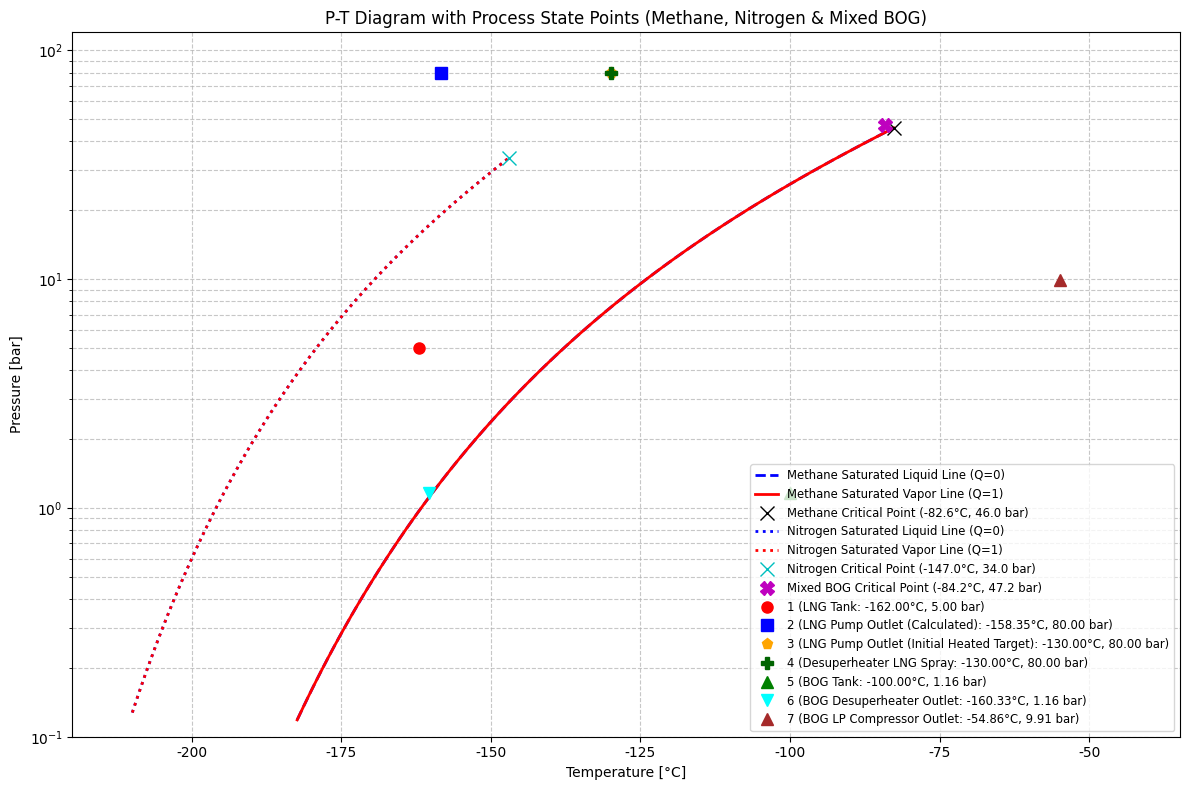

/tmp/ipykernel_454/1941339604.py:234: UserWarning: Glyph 47700 (\N{HANGUL SYLLABLE ME}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/1941339604.py:234: UserWarning: Glyph 53444 (\N{HANGUL SYLLABLE TAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/1941339604.py:234: UserWarning: Glyph 51656 (\N{HANGUL SYLLABLE JIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/1941339604.py:234: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47700 (\N{HANGUL SYLLABLE ME}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53444 (\N{HANGUL SYLLABLE TAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dis

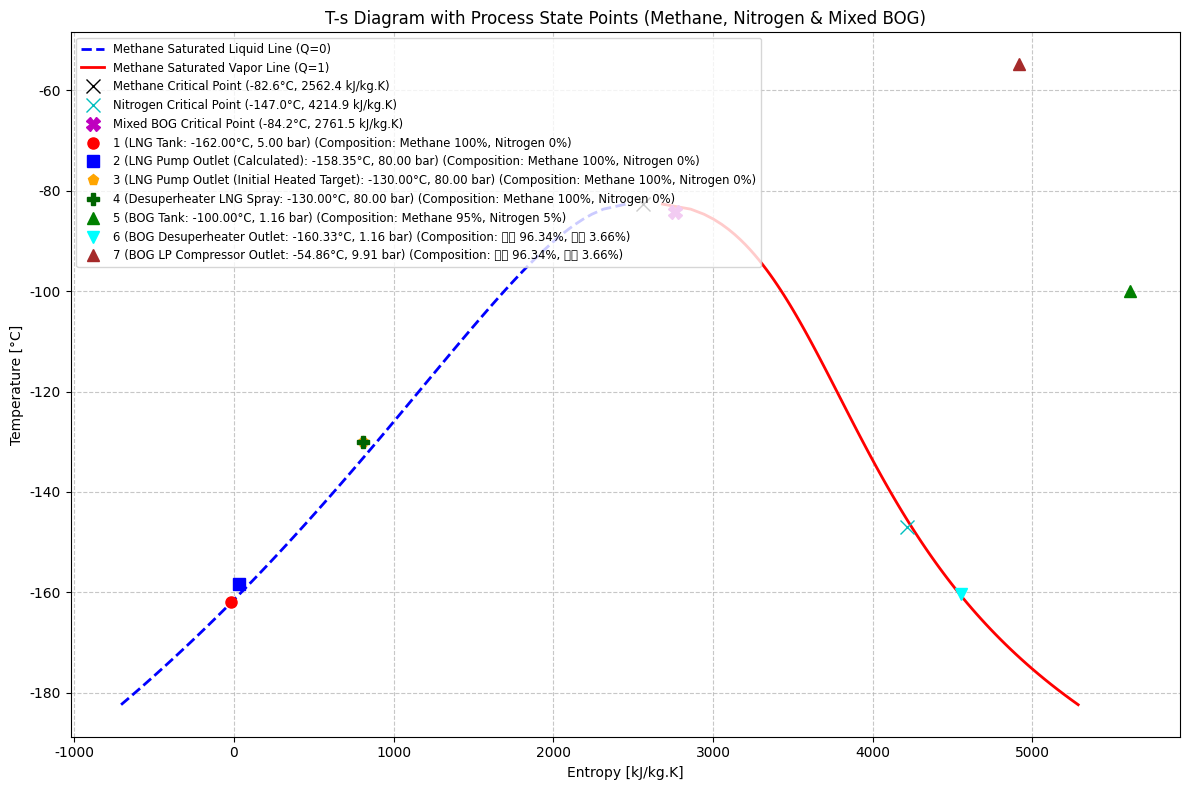

In [10]:
# @title 선도
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

# --- Configure matplotlib for default English font support ---
# Ensure unicode minus is handled (use hyphen instead of unicode minus)
plt.rcParams['axes.unicode_minus'] = False
# Remove specific Korean font configuration to avoid errors and use default English fonts
# as requested by the user if Korean fonts cause issues.
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans']


# --- Methane Critical Point ---
Tc_K_methane = CP.PropsSI('Tcrit', FLUID_LNG)
Pc_Pa_methane = CP.PropsSI('Pcrit', FLUID_LNG)
Tc_C_methane = K_to_C(Tc_K_methane)
Pc_bar_methane = Pa_to_bar(Pc_Pa_methane)

# --- Methane Saturation Curve Data for P-T diagram ---
# Generate temperatures from triple point to critical point
T_triple_K_methane = CP.PropsSI('Ttriple', FLUID_LNG)
T_sat_K_values_methane = np.linspace(T_triple_K_methane + 0.1, Tc_K_methane - 0.1, 100) # Avoid exact critical point for sat curve

P_sat_liquid_Pa_values_methane = []
P_sat_vapor_Pa_values_methane = []

for T_K in T_sat_K_values_methane:
    try:
        P_sat_liquid_Pa_values_methane.append(CP.PropsSI('P', 'T', T_K, 'Q', 0, FLUID_LNG)) # Saturation pressure for liquid (Q=0)
        P_sat_vapor_Pa_values_methane.append(CP.PropsSI('P', 'T', T_K, 'Q', 1, FLUID_LNG)) # Saturation pressure for vapor (Q=1)
    except ValueError:
        P_sat_liquid_Pa_values_methane.append(np.nan) # Handle cases where P_sat might not be found
        P_sat_vapor_Pa_values_methane.append(np.nan)

P_sat_liquid_bar_values_methane = [Pa_to_bar(p) if not np.isnan(p) else np.nan for p in P_sat_liquid_Pa_values_methane]
P_sat_vapor_bar_values_methane = [Pa_to_bar(p) if not np.isnan(p) else np.nan for p in P_sat_vapor_Pa_values_methane]
T_sat_C_values_methane = [K_to_C(t) for t in T_sat_K_values_methane]

# --- Nitrogen Critical Point ---
FLUID_NITROGEN = 'Nitrogen'
Tc_K_nitrogen = CP.PropsSI('Tcrit', FLUID_NITROGEN)
Pc_Pa_nitrogen = CP.PropsSI('Pcrit', FLUID_NITROGEN)
Tc_C_nitrogen = K_to_C(Tc_K_nitrogen)
Pc_bar_nitrogen = Pa_to_bar(Pc_Pa_nitrogen)

# --- Nitrogen Saturation Curve Data for P-T diagram ---
T_triple_K_nitrogen = CP.PropsSI('Ttriple', FLUID_NITROGEN)
T_sat_K_values_nitrogen = np.linspace(T_triple_K_nitrogen + 0.1, Tc_K_nitrogen - 0.1, 100)

P_sat_liquid_Pa_values_nitrogen = []
P_sat_vapor_Pa_values_nitrogen = []

for T_K in T_sat_K_values_nitrogen:
    try:
        P_sat_liquid_Pa_values_nitrogen.append(CP.PropsSI('P', 'T', T_K, 'Q', 0, FLUID_NITROGEN))
        P_sat_vapor_Pa_values_nitrogen.append(CP.PropsSI('P', 'T', T_K, 'Q', 1, FLUID_NITROGEN))
    except ValueError:
        P_sat_liquid_Pa_values_nitrogen.append(np.nan)
        P_sat_vapor_Pa_values_nitrogen.append(np.nan)

P_sat_liquid_bar_values_nitrogen = [Pa_to_bar(p) if not np.isnan(p) else np.nan for p in P_sat_liquid_Pa_values_nitrogen]
P_sat_vapor_bar_values_nitrogen = [Pa_to_bar(p) if not np.isnan(p) else np.nan for p in P_sat_vapor_Pa_values_nitrogen]
T_sat_C_values_nitrogen = [K_to_C(t) for t in T_sat_K_values_nitrogen]

# --- Define the state points to plot (aligned with df_streams_full) ---
state_points = [
    # 1. LNG Tank
    {'label': f"1 (LNG Tank: {results['LNG_TANK_T_C']:.2f}°C, {results['LNG_TANK_P_BAR']:.2f} bar)",
     'T_C': results['LNG_TANK_T_C'], 'P_bar': results['LNG_TANK_P_BAR'], 'marker': 'o', 'color': 'red'},
    # 2. LNG Pump Outlet (Calculated)
    {'label': f"2 (LNG Pump Outlet (Calculated): {results['LNG_PUMP_OUT_CALC_T_C']:.2f}°C, {results['LNG_PUMP_OUT_P_BAR']:.2f} bar)",
     'T_C': results['LNG_PUMP_OUT_CALC_T_C'], 'P_bar': results['LNG_PUMP_OUT_P_BAR'], 'marker': 's', 'color': 'blue'},
    # 3. LNG Pump Outlet (Initial Heated Target)
    {'label': f"3 (LNG Pump Outlet (Initial Heated Target): {K_to_C(params['T_lng_pump_out_heated']):.2f}°C, {results['LNG_PUMP_OUT_P_BAR']:.2f} bar)",
     'T_C': K_to_C(params['T_lng_pump_out_heated']), 'P_bar': results['LNG_PUMP_OUT_P_BAR'], 'marker': 'p', 'color': 'orange'},
    # 4. BOG Desuperheater LNG Spray (This is the LNG stream that goes into the desuperheater)
    {'label': f"4 (Desuperheater LNG Spray: {K_to_C(params['T_lng_pump_out_heated']):.2f}°C, {Pa_to_bar(params['P_lng_high']):.2f} bar)",
     'T_C': K_to_C(params['T_lng_pump_out_heated']), 'P_bar': Pa_to_bar(params['P_lng_high']), 'marker': 'P', 'color': 'darkgreen'},
    # 5. BOG Tank
    {'label': f"5 (BOG Tank: {results['BOG_TANK_T_C']:.2f}°C, {results['BOG_TANK_P_BAR']:.2f} bar)",
     'T_C': results['BOG_TANK_T_C'], 'P_bar': results['BOG_TANK_P_BAR'], 'marker': '^', 'color': 'green'},
    # 6. BOG Desuperheater Outlet (Mixed BOG + LNG Spray)
    {'label': f"6 (BOG Desuperheater Outlet: {results['BOG_DESUPERHEATER_OUT_T_C']:.2f}°C, {results['BOG_TANK_P_BAR']:.2f} bar)",
     'T_C': results['BOG_DESUPERHEATER_OUT_T_C'], 'P_bar': results['BOG_TANK_P_BAR'], 'marker': 'v', 'color': 'cyan'},
    # 7. BOG LP Compressor Outlet
    {'label': f"7 (BOG LP Compressor Outlet: {results['BOG_COMP_OUT_T_C']:.2f}°C, {results['BOG_COMP_OUT_P_BAR']:.2f} bar)",
     'T_C': results['BOG_COMP_OUT_T_C'], 'P_bar': results['BOG_COMP_OUT_P_BAR'], 'marker': '^', 'color': 'brown'}
]

# --- Plotting the P-T Diagram ---
fig_pt_diag = plt.figure(figsize=(12, 8)) # Assign to a variable for potential saving, larger figure

# Methane Saturation Curves
plt.plot(T_sat_C_values_methane, P_sat_liquid_bar_values_methane, 'b--', linewidth=2, label='Methane Saturated Liquid Line (Q=0)')
plt.plot(T_sat_C_values_methane, P_sat_vapor_bar_values_methane, 'r-', linewidth=2, label='Methane Saturated Vapor Line (Q=1)')
plt.plot(Tc_C_methane, Pc_bar_methane, 'kx', markersize=10, label=f'Methane Critical Point ({Tc_C_methane:.1f}°C, {Pc_bar_methane:.1f} bar)')

# Nitrogen Saturation Curves
plt.plot(T_sat_C_values_nitrogen, P_sat_liquid_bar_values_nitrogen, 'b:', linewidth=2, label='Nitrogen Saturated Liquid Line (Q=0)') # Dotted line for Nitrogen
plt.plot(T_sat_C_values_nitrogen, P_sat_vapor_bar_values_nitrogen, 'r:', linewidth=2, label='Nitrogen Saturated Vapor Line (Q=1)')   # Dotted line for Nitrogen
plt.plot(Tc_C_nitrogen, Pc_bar_nitrogen, 'cx', markersize=10, label=f'Nitrogen Critical Point ({Tc_C_nitrogen:.1f}°C, {Pc_bar_nitrogen:.1f} bar)') # Cyan cross for Nitrogen critical point

# Add the BOG Fluid for its critical point, if it has one defined by CoolProp
try:
    Tc_K_bog_mix = CP.PropsSI('Tcrit', results['FLUID_BOG_AFTER_DESUPERHEATER'])
    Pc_Pa_bog_mix = CP.PropsSI('Pcrit', results['FLUID_BOG_AFTER_DESUPERHEATER'])
    Tc_C_bog_mix = K_to_C(Tc_K_bog_mix)
    Pc_bar_bog_mix = Pa_to_bar(Pc_Pa_bog_mix)
    plt.plot(Tc_C_bog_mix, Pc_bar_bog_mix, 'mX', markersize=10, label=f'Mixed BOG Critical Point ({Tc_C_bog_mix:.1f}°C, {Pc_bar_bog_mix:.1f} bar)')
except ValueError:
    # print(f"Warning: Critical point for mixed BOG fluid '{results['FLUID_BOG_AFTER_DESUPERHEATER']}' not found. Skipping plot.")
    pass # Critical point might not be defined for some mixtures

# Plotting saturation curves for the mixed BOG fluid is more complex and usually involves flash calculations.
# For a simplified plot, we will stick to pure component saturation curves and plot mixture points.


for point in state_points:
    plt.plot(point['T_C'], point['P_bar'], point['marker'], color=point['color'], markersize=8, label=point['label'])

plt.title('P-T Diagram with Process State Points (Methane, Nitrogen & Mixed BOG)')
plt.xlabel('Temperature [°C]')
plt.ylabel('Pressure [bar]')
plt.yscale('log') # Pressure often spans several orders of magnitude, so log scale is useful
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.legend(loc='best', fontsize='small')
plt.xlim(min(min(T_sat_C_values_methane), min(T_sat_C_values_nitrogen), results['BOG_DESUPERHEATER_OUT_T_C']) - 10, max([p['T_C'] for p in state_points]) + 20)
plt.ylim(0.1, max(Pc_bar_methane, Pc_bar_nitrogen, max([p['P_bar'] for p in state_points])) * 1.5)
plt.tight_layout()
plt.show()


# --- Methane Saturation Curve Data for T-s diagram ---
T_sat_K_values_ts_methane = np.linspace(T_triple_K_methane + 0.1, Tc_K_methane - 0.1, 100) # Avoid exact critical point

s_sat_liquid_values_methane = []
s_sat_vapor_values_methane = []

for T_K in T_sat_K_values_ts_methane:
    try:
        # For saturated liquid and vapor entropy, we specify T and Q
        s_sat_liquid_values_methane.append(CP.PropsSI('Smass', 'T', T_K, 'Q', 0, FLUID_LNG)) # Saturated liquid entropy (Q=0)
        s_sat_vapor_values_methane.append(CP.PropsSI('Smass', 'T', T_K, 'Q', 1, FLUID_LNG)) # Saturated vapor entropy (Q=1)
    except ValueError:
        s_sat_liquid_values_methane.append(np.nan)
        s_sat_vapor_values_methane.append(np.nan)

T_sat_C_values_ts_methane = [K_to_C(t) for t in T_sat_K_values_ts_methane]

# --- Nitrogen Saturation Curve Data for T-s diagram ---
T_sat_K_values_ts_nitrogen = np.linspace(T_triple_K_nitrogen + 0.1, Tc_K_nitrogen - 0.1, 100) # Avoid exact critical point

s_sat_liquid_values_nitrogen = []
s_sat_vapor_values_nitrogen = []

for T_K in T_sat_K_values_ts_nitrogen:
    try:
        s_sat_liquid_values_nitrogen.append(CP.PropsSI('Smass', 'T', T_K, 'Q', 0, FLUID_NITROGEN))
        s_sat_vapor_values_nitrogen.append(CP.PropsSI('Smass', 'T', T_K, 'Q', 1, FLUID_NITROGEN))
    except ValueError:
        s_sat_liquid_values_nitrogen.append(np.nan)
        s_sat_vapor_values_nitrogen.append(np.nan)

T_sat_C_values_ts_nitrogen = [K_to_C(t) for t in T_sat_K_values_ts_nitrogen]

# --- Calculate entropy for existing state points (considering actual fluid) ---
state_points_ts = []
for i, point in enumerate(state_points):
    T_K_point = C_to_K(point['T_C'])
    P_Pa_point = bar_to_Pa(point['P_bar'])
    fluid_for_entropy = FLUID_LNG # Default for LNG stream
    composition_label = ""

    # Use correct fluid for BOG streams
    if i == 4: # BOG Tank
        fluid_for_entropy = FLUID
        composition_label = composition_str_bog
    elif i == 5 or i == 6: # BOG Desuperheater Outlet and BOG LP Compressor Outlet
        fluid_for_entropy = results['FLUID_BOG_AFTER_DESUPERHEATER']
        composition_label = results['COMPOSITION_STR_BOG_AFTER_DESUPERHEATER']
    else:
        composition_label = composition_str_lng

    try:
        s_point = s_TP(T_K_point, P_Pa_point, fluid_for_entropy)
    except ValueError:
        s_point = np.nan # Handle cases where entropy might not be found

    state_points_ts.append(
        {
            'label': f"{point['label']} (Composition: {composition_label})",
            'T_C': point['T_C'],
            's': s_point,
            'marker': point['marker'],
            'color': point['color'],
        }
    )


# --- Plotting the T-s Diagram ---
fig_ts_diag = plt.figure(figsize=(12, 8))

# Methane Saturation Curves
plt.plot(s_sat_liquid_values_methane, T_sat_C_values_ts_methane, 'b--', linewidth=2, label='Methane Saturated Liquid Line (Q=0)')
plt.plot(s_sat_vapor_values_methane, T_sat_C_values_ts_methane, 'r-', linewidth=2, label='Methane Saturated Vapor Line (Q=1)')

# Methane Critical Point
s_crit_methane = s_TP(Tc_K_methane, Pc_Pa_methane, FLUID_LNG)
plt.plot(s_crit_methane, Tc_C_methane, 'kx', markersize=10, label=f'Methane Critical Point ({Tc_C_methane:.1f}°C, {s_crit_methane:.1f} kJ/kg.K)')

# Nitrogen Critical Point
s_crit_nitrogen = s_TP(Tc_K_nitrogen, Pc_Pa_nitrogen, FLUID_NITROGEN)
plt.plot(s_crit_nitrogen, Tc_C_nitrogen, 'cx', markersize=10, label=f'Nitrogen Critical Point ({Tc_C_nitrogen:.1f}°C, {s_crit_nitrogen:.1f} kJ/kg.K)')

# Add Mixed BOG critical point if available
try:
    s_crit_bog_mix = s_TP(Tc_K_bog_mix, Pc_Pa_bog_mix, results['FLUID_BOG_AFTER_DESUPERHEATER'])
    plt.plot(s_crit_bog_mix, Tc_C_bog_mix, 'mX', markersize=10, label=f'Mixed BOG Critical Point ({Tc_C_bog_mix:.1f}°C, {s_crit_bog_mix:.1f} kJ/kg.K)')
except (ValueError, NameError):
    pass

# Plot Process State Points
for point in state_points_ts:
    if not np.isnan(point['s']):
        plt.plot(point['s'], point['T_C'], point['marker'], color=point['color'], markersize=8, label=point['label'])

plt.title('T-s Diagram with Process State Points (Methane, Nitrogen & Mixed BOG)')
plt.xlabel('Entropy [kJ/kg.K]')
plt.ylabel('Temperature [°C]')
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
plt.show()

In [13]:
# @title
import pandas as pd

# Create list for power consumption data
power_data = []

power_data.append({
    "Equipment": "LNG Pump",
    "Power Consumption [MW]": results["LNG_PUMP_POWER_MW"],
    "Efficiency / Effectiveness": params["pump_eta"]
})
power_data.append({
    "Equipment": "BOG Compressor",
    "Power Consumption [MW]": results["BOG_COMP_POWER_MW"],
    "Efficiency / Effectiveness": params["comp_eta"]
})
power_data.append({
    "Equipment": "Desuperheater",
    "Power Consumption [MW]": "N/A", # Heat exchangers do not consume power
    "Efficiency / Effectiveness": "N/A" # Desuperheater is now spray mixing, no efficiency/effectiveness parameter
})

# Add total power consumption
power_data.append({
    "Equipment": "Total System Power",
    "Power Consumption [MW]": results["TOTAL_POWER_MW"],
    "Efficiency / Effectiveness": "N/A" # Total system power does not have individual efficiency
})

# Create DataFrame
df_power_summary = pd.DataFrame(power_data)

print("\n=== Equipment Power Consumption Summary ===")
display(df_power_summary.round(3))


=== Equipment Power Consumption Summary ===


,Equipment,Power Consumption [MW],Efficiency / Effectiveness
0,LNG Pump,1.527778,0.75
1,BOG Compressor,2.02071,0.665
2,Desuperheater,N/A,N/A
3,Total System Power,3.548488,N/A


In [14]:
mermaid_diagram_code = """graph TD
    subgraph LNG Stream
        A[LNG Tank] --> B(LNG Pump)
        B --> C(LNG Preheater)
        C --> D{Desuperheater (LNG Cooling Side)}
    end

    subgraph BOG Stream
        E[BOG Tank] --> F{Desuperheater (BOG Heating Side)}
        F --> G(BOG LP Compressor)
    end

    D -- Cooled LNG --> H[LNG Process End]
    G -- Compressed BOG --> I[BOG Process End]

    style A fill:#f9f,stroke:#333,stroke-width:2px
    style E fill:#f9f,stroke:#333,stroke-width:2px
    style H fill:#f9f,stroke:#333,stroke-width:2px
    style I fill:#f9f,stroke:#333,stroke-width:2px
"""

print("Mermaid diagram code generated.")

Mermaid diagram code generated.


## Simplified LNG Vaporization Process System Diagram

Google Colab's Markdown cells do not directly render Mermaid diagrams as images. To view the visualized diagram, you can paste the code below into an online tool like Mermaid Live Editor (https://mermaid.live/).

```mermaid
graph TD
    subgraph LNG Stream
        A[LNG Tank] --> B(LNG Pump)
        B --> C(LNG Preheater)
        C --> D{Desuperheater (LNG Cooling Side)}
    end

    subgraph BOG Stream
        E[BOG Tank] --> F{Desuperheater (BOG Heating Side)}
        F --> G(BOG LP Compressor)
    end

    D -- Cooled LNG --> H[LNG Process End]
    G -- Compressed BOG --> I[BOG Process End]

    style A fill:#f9f,stroke:#333,stroke-width:2px
    style E fill:#f9f,stroke:#333,stroke-width:2px
    style H fill:#f9f,stroke:#333,stroke-width:2px
    style I fill:#f9f,stroke:#333,stroke-width:2px
```